In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import scipy as sp
#import pyccl as ccl
import math
import matplotlib.pyplot as plt

from mpl_toolkits.mplot3d import Axes3D
from scipy import integrate
from functools import partial
from scipy.integrate import quad, dblquad

import pyccl as ccl
import camb
from camb import model, initialpower
import cosmology
import fisher_matrix_local_png
import fisher_matrix_rsd
import power_spectrum_information

In [2]:
h=0.677
deltac=1.686
H0=100*h
c_ls=300*10**3
nlim=10000
n_s=0.968

cosmo = ccl.Cosmology(Omega_c=0.27, Omega_b=0.045, h=h, A_s=2.1e-9, n_s=n_s,transfer_function='boltzmann_camb')
s8_z0 = ccl.sigma8(cosmo)

In [3]:
N_zm_u = np.load(f'../target_selection/photom_redshift_distribution/COSMOS_LBG_udropout_highz.npz')
N_zm_g = np.load(f'../target_selection/photom_redshift_distribution/COSMOS_LBG_gdropout.npz')
N_zm_r = np.load(f'../target_selection/photom_redshift_distribution/COSMOS_LBG_rdropout.npz')
samples = [N_zm_u, N_zm_g, N_zm_r]

In [4]:
mag_max = [25.2,25.2,25.2]
bias = [3,4,5]
constraints1 = []
constraints2 = []
for i, s in enumerate(samples[0:]):
    print(i)
    sample = samples[i]
    z_centers, mag_centers =  sample['z_center'], sample['mag_center'] 
    zarray = z_centers[z_centers > 2]
    S = 1.6
    S_survey = 18000
    time_one_pass = 15 # minutes
    n_zm_target = sample['object_count']/S
    n_zm_target[:,(mag_centers > mag_max[i])] = 0
    nz = np.sum(n_zm_target, axis=1)[z_centers > 2]
    N_degm2 = np.sum(nz)
    bz = bias[i] * np.ones(len(z_centers))[z_centers > 2]
    #list_zbin, list_sigma_bs8, list_sigma_fs8, zeff, sigma_bs8_eff, sigma_fs8_eff=fisher_matrix_rsd_mono_and_quadru_poles.sigma_multipoles_single_tracer(zarray,nz,bz,Area,N_degm2,Deltaz=0.4,kmax=0.1,multipoles='both',cosmo=cosmo)
    #constraints1.append([list_zbin, list_sigma_bs8, list_sigma_fs8, zeff, sigma_bs8_eff, sigma_fs8_eff])
    list_zbin, list_sigma_bs8, list_sigma_fs8, zeff, sigma_bs8_eff, sigma_fs8_eff=fisher_matrix_rsd.sigma_rsd_single_tracer(zarray,nz,bz,S_survey,N_degm2,Deltaz=0.4,kmax=0.1,cosmo=cosmo)
    constraints2.append([list_zbin, list_sigma_bs8, list_sigma_fs8, zeff, sigma_bs8_eff, sigma_fs8_eff])

0
1
2


0.7104835128348126
1.0164841877293351
1.966165763799481


(1.0, 6.0)

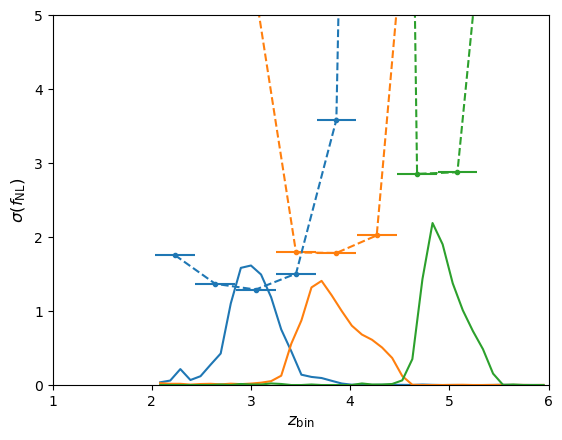

In [5]:
mag_max = [25.5,25.5,25.5]
bias = [3,4,5]
for i, s in enumerate(samples):
    sample = samples[i]
    z_centers, mag_centers =  sample['z_center'], sample['mag_center'] 
    zarray = z_centers[z_centers > 2]
    S = 1.6
    S_survey = 18000
    time_one_pass = 15 # minutes
    n_zm_target = sample['object_count']/S
    n_zm_target[:,(mag_centers > mag_max[i])] = 0
    nz = np.sum(n_zm_target, axis=1)[z_centers > 2]
    N_degm2 = np.sum(nz)
    #bz = bias[i] * np.ones(len(z_centers))[z_centers > 2]
    #plt.errorbar(constraints1[i][0],100*np.array(constraints1[i][2]),xerr=0.2,marker='.',linestyle='-',color='C'+str(i), label = 'per-redshift bin constraint')

    plt.errorbar(constraints2[i][0],100*np.array(constraints2[i][2]),xerr=0.2,marker='.',linestyle='--',color='C'+str(i), label = 'per-redshift bin constraint')
    #plt.errorbar(constraints[i][0],constraints[i][2],marker='x', color='C'+str(i), label = 'Combined constraint')
    print(100*constraints2[i][5])
    plt.plot(zarray, nz/np.trapezoid(nz, zarray), label = 'n(z) not normalized')
plt.ylabel(r'$\sigma(f_{\rm NL})$',fontsize=12)
plt.xlabel(r'$z_{\rm bin}$',fontsize=12)
plt.ylim(0, 5)

#plt.yscale('log')

plt.xlim(1, 6)

1.7239396591606344
1.0011747705481437
0.3200449930391888


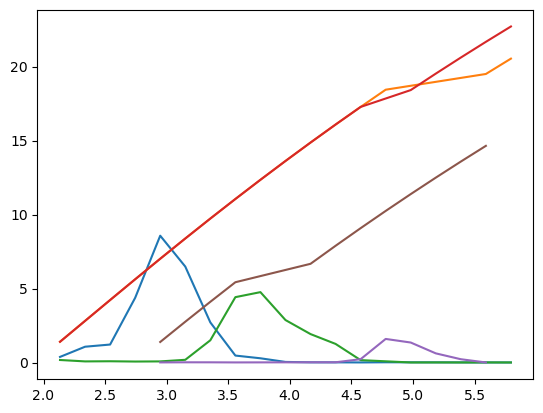

In [6]:
mag_max = [25.2,25.2,25.2]
bias = [3,4,5]
constraints = []
for i, s in enumerate(samples):
    sample = samples[i]
    z_centers, mag_centers =  sample['z_center'], sample['mag_center'] 
    zarray = z_centers[z_centers > 2]
    S = 1.6
    S_survey = 18000
    time_one_pass = 15 # minutes
    n_zm_target = sample['object_count']/S
    n_zm_target[:,(mag_centers > mag_max[i])] = 0
    nz = np.sum(n_zm_target, axis=1)[z_centers > 2]
    N_degm2 = np.sum(nz)
    bz = bias[i] * np.ones(len(z_centers))[z_centers > 2]
    list_zbin, list_n, list_b, list_Pm, list_nP, list_Vsur =power_spectrum_information.compute_nbP(
        zarray, nz, bz,
        S_survey, N_degm2,
        k=0.001,
        Deltaz=0.2,
        cosmo=cosmo
    )
    print(np.average(list_nP, weights=list_Vsur))
    plt.plot(list_zbin, np.array(list_nP), label = 0.1)
    plt.plot(list_zbin, np.cumsum(np.array(list_Vsur))/1e10, label = 0.1)